# Chương 5: Mô Hình Sequence-to-Sequence

> *"Theo lý trời đất và vạn vật, không gì tồn tại đơn độc mà mọi thứ đều có đối lập."*
> — Zhu Xi & Lv Zuqian (AD 1130-1200)

Trong ngôn ngữ, mọi thứ thường đi thành đôi: câu hỏi-câu trả lời, văn bản tiếng Anh-bản dịch tiếng Việt, câu-cây cú pháp. Chương này mô hình hóa sự tương ứng giữa các cặp đó.

---

# 5.1 Bài Toán Sequence-to-Sequence

## Formulation Tổng Quát

$$\hat{y} = \arg\max_y \Pr(y \mid x) = \arg\max_{y_1\ldots y_n} \Pr(y_1\ldots y_n \mid x_1\ldots x_m) \tag{5.2, 5.3}$$

**Khác với classification:** Output $\hat{y}$ không chọn từ tập cố định mà từ **không gian chuỗi cực kỳ lớn** (exponentially large) → cần mô hình mạnh hơn và thuật toán tìm kiếm hiệu quả hơn.

---

## Ba Vấn Đề Cốt Lõi

**1. Modeling** — Định nghĩa dạng của $\Pr(y \mid x)$:
→ Dùng **encoder-decoder architecture** + **attention mechanism** (một mạng neural duy nhất)

**2. Training** — Học tham số từ dữ liệu:
→ Optimize loss function bằng gradient descent (như Chương 2)

**3. Search / Decoding** — Tìm $\hat{y}$ tối đa hóa $\Pr(y \mid x)$:
→ Thách thức tính toán lớn — số chuỗi candidate tăng theo độ dài và vocabulary size
→ Mục 5.4 sẽ trình bày các phương pháp tìm kiếm hiệu quả

---

## Các Bài Toán Seq2Seq Phổ Biến

| Task | Source | Target |
|---|---|---|
| **Machine Translation** | Văn bản ngôn ngữ A | Văn bản ngôn ngữ B |
| **Question Answering** | Câu hỏi | Câu trả lời |
| **Dialogue Systems** | Text/Speech | Response |
| **Summarization** | Văn bản dài | Tóm tắt |
| **Text Simplification** | Văn bản phức tạp | Văn bản đơn giản |
| **Grammar Correction** | Văn bản có lỗi | Văn bản đúng |
| **Speech Recognition** | Giọng nói | Văn bản |
| **Speech Synthesis** | Văn bản | Giọng nói |
| **Image Captioning** | Ảnh (2D) | Mô tả văn bản |

> **Insight quan trọng:** Dù các task này phát triển độc lập trong lịch sử với kiến trúc riêng biệt, khi biểu diễn bằng neural network và train end-to-end, chúng chia sẻ một **paradigm chung**. Đây là bước ngoặt lớn trong AI — các lĩnh vực nghiên cứu hội tụ lại.

---

## Tổng Kết Mục 5.1

```
Seq2Seq: x = x₁...xm → y = y₁...yn
         (source sequence)  (target sequence)

Ba vấn đề:
  Modeling  → Encoder-Decoder + Attention (Mục 5.2, 5.3)
  Training  → MLE + Gradient Descent
  Decoding  → Beam Search, Greedy (Mục 5.4)

Khác classification:
  Output space: exponentially large (không phải tập cố định)
  → Cần search algorithm, không chỉ argmax đơn giản
```

Bạn gửi tiếp nội dung Mục 5.2 (Encoder-Decoder) để tiếp tục nhé!

# 5.2 Kiến Trúc Encoder-Decoder

---

## 5.2.1 Encoding và Decoding

### Ý Tưởng Cốt Lõi

Ánh xạ trực tiếp $x \to y$ trên không gian chuỗi rời rạc chiều cao → **curse of dimensionality**. Giải pháp: chia thành hai bước qua **biểu diễn trung gian $H$ chiều thấp**:

**Encoder:**
$$H = \text{Encode}(x) \tag{5.4}$$

**Decoder:**
$$\Pr(\cdot \mid H) = \text{Decode}(H) \tag{5.6}$$

$$\Pr(y \mid x) = \Pr(y \mid H) \tag{5.7}$$

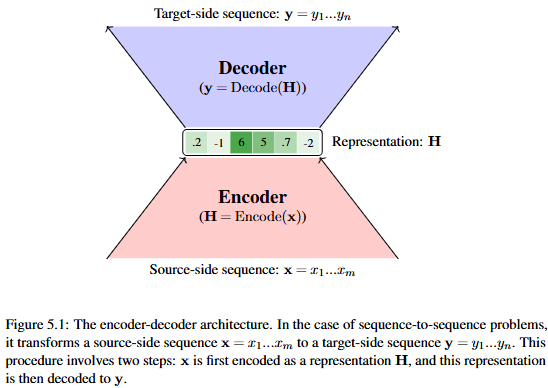

**Toàn bộ hệ thống là một neural network duy nhất** — train end-to-end bằng gradient descent.

> **Kết nối:** Auto-encoder (Chương 2) là trường hợp đặc biệt của encoder-decoder khi $x = y$ — encoder nén, decoder tái tạo.

---

## 5.2.2 Ví Dụ — Neural Machine Translation (NMT)

### Encoder

Source vocabulary $V_x$, mỗi từ $x_j$ → word embedding → RNN:

$$x_j^e = \text{Embed}_s(x_j) \tag{5.8}$$

$$h_j = \text{RNN}(h_{j-1}, x_j^e) \tag{5.9}$$

**Representation của toàn bộ source sequence:**

$$H = h_m = \text{Encode}(x_1\ldots x_m) \tag{5.10}$$

Trạng thái cuối $h_m$ **nén toàn bộ source sequence** thành một vectơ duy nhất.

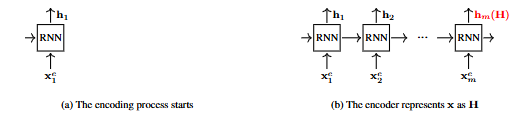

### Decoder

Decoder là **RNN language model** dự đoán từ target tiếp theo, khởi tạo từ $H$:

**Khởi tạo** — dùng $h_m$ và token $\langle\text{SOS}\rangle$:

$$s_0 = \text{RNN}(h_m, y_0^e) \tag{5.11}$$

**Cập nhật state** tại các bước tiếp theo:

$$s_i = \text{RNN}(s_{i-1}, y_i^e) \tag{5.12}$$

**Dự đoán từ tiếp theo:**

$$\Pr(\cdot \mid y_1\ldots y_i, x_1\ldots x_m) = \text{Softmax}(s_i U_y + b_y) \tag{5.13}$$

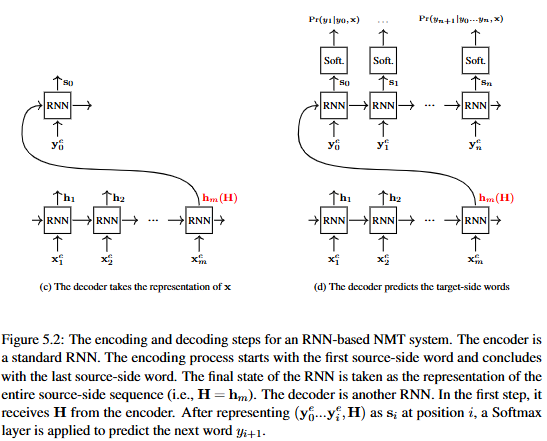

### Xác Suất Toàn Bộ Chuỗi Target

$$\Pr(y \mid x) = \prod_{i=0}^{n-1} \Pr(y_{i+1} \mid y_0\ldots y_i, x_1\ldots x_m) \tag{5.14}$$

Với $\langle\text{SOS}\rangle$ và $\langle\text{EOS}\rangle$ đầy đủ:

$$\Pr(y_0\ldots y_{n+1} \mid x_0\ldots x_{m+1}) = \prod_{i=0}^n \Pr(y_{i+1} \mid y_0\ldots y_i, x_0\ldots x_{m+1}) \tag{5.16}$$

**Training:** Cross-entropy loss + gradient descent (giống RNN language model Chương 4).

---

## Tổng Kết Mục 5.2

```
Encoder-Decoder NMT:

SOURCE: x₁...xm
  ↓ Embedding
x₁ᵉ...xmᵉ
  ↓ Encoder RNN
h₁...hm → H = hm  (toàn bộ source nén vào 1 vector)
  ↓
TARGET: y₀ = ⟨SOS⟩
  ↓ Decoder RNN (khởi tạo từ H)
s₀ = RNN(hm, y₀ᵉ)
s₁ = RNN(s₀, y₁ᵉ)  → Pr(y₂|...)
...
sn → Pr(⟨EOS⟩|...)
```

**Vấn đề tiềm ẩn:** Toàn bộ source sequence bị nén vào **một vectơ duy nhất $h_m$** → với câu dài, thông tin đầu câu bị "pha loãng" → **information bottleneck**.

> **Giải pháp → Attention mechanism (Mục 5.3):** Thay vì chỉ dùng $h_m$, decoder có thể "nhìn lại" **tất cả** $h_1\ldots h_m$ khi dự đoán mỗi từ target → không còn bottleneck. Đây là nền tảng của Transformer.

# 5.3 Cơ Chế Attention

---

## Vấn Đề của Encoder-Decoder Thuần Túy

Trong NMT (Mục 5.2), toàn bộ source sequence bị nén vào **một vectơ duy nhất** $h_m$ → **information bottleneck**:
- Câu dài: thông tin đầu câu bị "pha loãng" qua nhiều bước RNN
- Decoder chỉ nhận một đại diện cố định, không phân biệt được phần nào của source quan trọng với từng từ target

**Giải pháp — Attention:** Với mỗi bước decode, tạo ra **biểu diễn thích ứng** tập trung vào các phần quan trọng của source sequence.

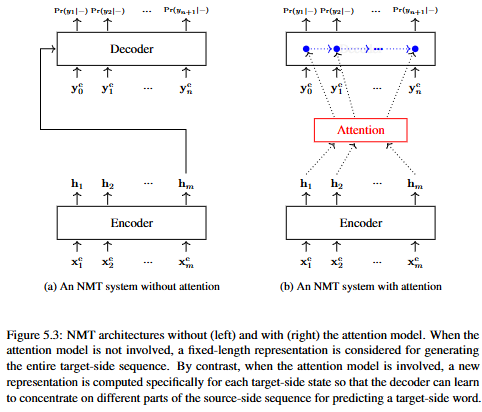

---

## 5.3.1 Mô Hình Attention Cơ Bản

### Context Vector

Thay vì chỉ dùng $h_m$, attention tạo **context vector $c_i$** cho mỗi bước decode $i$ — tổ hợp có trọng số của toàn bộ encoder states:

$$c_i = \sum_{j=1}^m \alpha_{i,j} \cdot h_j \tag{5.17}$$

**Attention weights** — chuẩn hóa alignment scores:

$$\alpha_{i,j} = \frac{\exp(a(s_i, h_j))}{\sum_{j'=1}^m \exp(a(s_i, h_{j'}))} \tag{5.18}$$

$\alpha_{i,j}$ đo mức độ từ target ở vị trí $i$ nên "chú ý" đến từ source ở vị trí $j$.

**Diễn giải xác suất:**

$$\Pr(h_j \mid s_i) = \alpha_{i,j}, \quad c_i = \mathbb{E}_{h \sim \Pr(h \mid s_i)}[h] \tag{5.24, 5.25}$$

$c_i$ là **kỳ vọng của source representations** dưới phân phối attention — decoder nhận thông tin từ $m$ "người gửi" $h_1\ldots h_m$ theo mức độ ưu tiên $\alpha_{i,j}$.

---

### Các Hàm Tính Alignment Score $a(s_i, h_j)$

**Dot-product Attention** — đơn giản nhất, đo cosine giữa hai vectơ:

$$a(s_i, h_j) = s_i h_j^\top = \sum_{k=1}^{d_h} s_i(k) \cdot h_j(k) \tag{5.19}$$

**Scaled Dot-product Attention** — chia thêm hệ số $\beta$ để ổn định gradient khi $d_h$ lớn:

$$a(s_i, h_j) = \frac{s_i h_j^\top}{\beta} \tag{5.20}$$

**Cosine Attention** — chuẩn hóa theo norm:

$$a(s_i, h_j) = \frac{s_i h_j^\top}{\|s_i\|_2 \cdot \|h_j\|_2} \tag{5.21}$$

**Weighted Dot-product (Multiplicative) Attention** — thêm linear transformation:

$$a(s_i, h_j) = s_i W_a h_j^\top, \quad W_a \in \mathbb{R}^{d_h \times d_h} \tag{5.22}$$

**Additive Attention (Bahdanau et al., 2014)** — kết hợp hai vectơ qua feed-forward:

$$a(s_i, h_j) = v_a^\top \text{TanH}(s_i W_s + h_j W_h) \tag{5.23}$$

với $W_h, W_s \in \mathbb{R}^{d_h \times d_a}$, $v_a \in \mathbb{R}^{d_a}$.

> **Tổng kết:** Dot-product nhanh, song song được; Additive chậm hơn nhưng linh hoạt hơn. Scaled dot-product là lựa chọn phổ biến nhất (được dùng trong Transformer).

---

### Tích Hợp Attention vào Decoder

Context vector $c_{i-1}$ được đưa vào decoder state tại bước $i$:

$$s_i = \text{RNN}(s_{i-1},\ c_{i-1},\ y_i^e) \tag{5.26}$$

So với (5.12) không có attention: thêm $c_{i-1}$ → decoder có cả thông tin target lịch sử ($s_{i-1}, y_i^e$) lẫn thông tin source thích ứng ($c_{i-1}$).

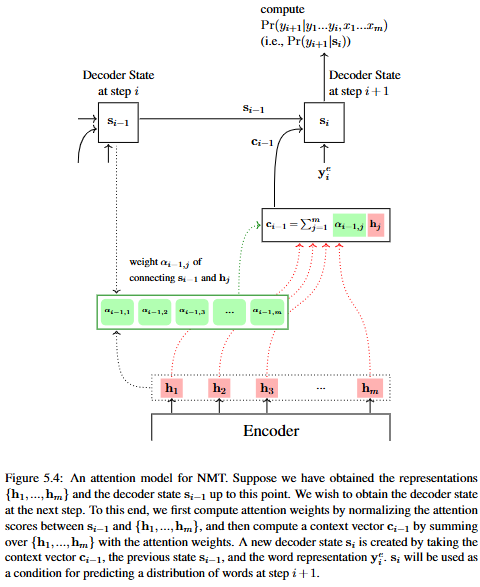

### Quy Trình Đầy Đủ của Attention NMT

```
1. Encode: hj = RNN(hj-1, xjᵉ) với j = 1..m

2. Decode (lặp từ i=1 đến n-1):
   a. Tính alignment: a(si-1, hj) với mỗi j
   b. Tính attention weights: αi-1,j = softmax(a(si-1,hj))
   c. Tính context vector: ci-1 = Σj αi-1,j · hj
   d. Cập nhật decoder: si = RNN(si-1, ci-1, yiᵉ)
   e. Dự đoán: Pr(·|si) = Softmax(si·Uy + by)
   f. Training: lấy yi+1 thực; Testing: yi+1 = argmax Pr(·|si)
```

---

## 5.3.2 QKV Attention

### Formulation Tổng Quát

Đặt lại bài toán attention dưới dạng **Query-Key-Value (QKV)** — nền tảng của Transformer.

**Ý tưởng:** Có $m$ cặp key-value $(k_1,v_1),\ldots,(k_m,v_m)$ và query $q$. Tìm tổ hợp có trọng số của values dựa trên sự tương đồng giữa query và keys:

$$c = \sum_{j=1}^m \alpha_j v_j, \quad \alpha_j = \frac{\exp(qk_j^\top/\beta)}{\sum_{j'} \exp(qk_{j'}^\top/\beta)} \tag{5.28, 5.29}$$

**Dạng ma trận** với $n$ queries $Q \in \mathbb{R}^{n \times d_h}$, $K \in \mathbb{R}^{m \times d_h}$, $V \in \mathbb{R}^{m \times d_h}$:

$$C = \text{Softmax}\!\left(\frac{QK^\top}{\beta}\right) V \tag{5.31}$$

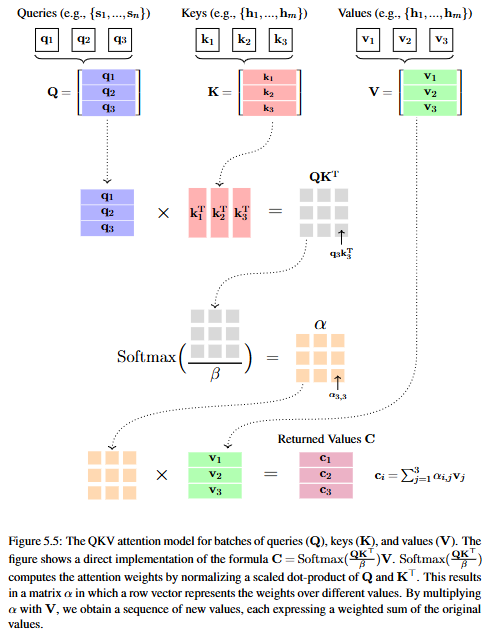

**Softmax row-wise:**

$$\text{Softmax}\!\left(\frac{QK^\top}{\beta}\right) = \begin{pmatrix}\alpha_{1,1}&\cdots&\alpha_{1,m}\\\vdots&&\vdots\\\alpha_{n,1}&\cdots&\alpha_{n,m}\end{pmatrix} \tag{5.32}$$

Mỗi hàng là phân phối attention của một query trên toàn bộ keys.

### Hai Cách Dùng QKV Attention

**Encoder-Decoder Attention** — ánh xạ source ↔ target:

$$Q = \begin{pmatrix}s_1\\\vdots\\s_n\end{pmatrix}, \quad K = V = \begin{pmatrix}h_1\\\vdots\\h_m\end{pmatrix} \tag{5.34, 5.35}$$

Mỗi target state $s_i$ query vào encoder states $h_1\ldots h_m$ → $c_i$ là biểu diễn source thích ứng với target.

**Self-Attention** — ánh xạ sequence lên chính nó:

$$Q = K = V = \begin{pmatrix}h_1\\\vdots\\h_m\end{pmatrix} \tag{5.36}$$

Mỗi $c_j$ capture **tương quan của $h_j$ với toàn bộ chuỗi** → contextualized representation. Đây là nền tảng của **Transformer** (Chương 6).

---

## 5.3.3 Multi-head Attention

**Ý tưởng:** Thay vì attention trong một không gian duy nhất, thực hiện attention **song song trong nhiều subspace** → capture nhiều loại quan hệ khác nhau cùng lúc (cú pháp, ngữ nghĩa, vị trí,...).

**Quy trình** với $\tau$ heads:

**Bước 1 — Project & Split:** Chiếu $H$ và $S$ xuống $\tau$ subspace:

$$H^{\text{heads}} \in \mathbb{R}^{\tau \times m \times d_h/\tau} = \text{Split}(HW_h, \tau)$$
$$S^{\text{heads}} \in \mathbb{R}^{\tau \times n \times d_h/\tau} = \text{Split}(SW_s, \tau)$$

**Bước 2 — Attention song song** trên từng head:

$$C^{\text{heads}} = \text{Att}(H^{\text{heads}}, S^{\text{heads}}) \in \mathbb{R}^{\tau \times n \times d_h/\tau}$$

**Bước 3 — Merge & Project:** Ghép các heads lại, chiếu về chiều gốc:

$$C = \text{Merge}(C^{\text{heads}}, \tau) \cdot W_c \in \mathbb{R}^{n \times d_h}$$

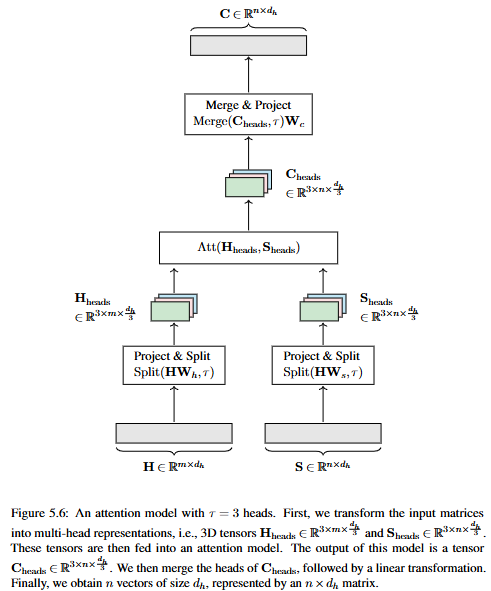

**Ưu điểm:**
- Mỗi head học một loại quan hệ khác nhau
- Các heads chạy **song song** → hiệu quả tính toán
- Tổng số tham số tương đương single-head

---

## 5.3.4 Multi-layer Attention

**Xếp chồng nhiều lớp attention** để tạo biểu diễn sâu hơn:

$$S^l = \text{FFN}(\text{Att}(H, S^{l-1})) + S^{l-1} \tag{5.57}$$

Hoặc dạng tường minh:

1. $C^l = \text{Att}(H, S^{l-1})$ — attention lấy $H$ làm key/value, $S^{l-1}$ làm query
2. $S^l = \text{FFN}(C^l) + S^{l-1}$ — FFN + residual connection

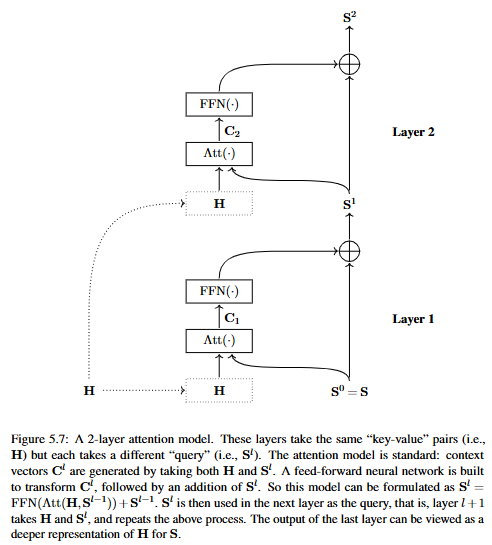

**Đặc điểm:**
- Tất cả layers dùng cùng $H$ (source encoding không đổi)
- Query $S^{l-1}$ cập nhật qua từng layer → biểu diễn ngày càng sâu
- **Residual connection** $+S^{l-1}$ đảm bảo gradient flow tốt

---

## 5.3.5 Các Nhận Xét Quan Trọng

### 1. Word Alignment vs. Attention

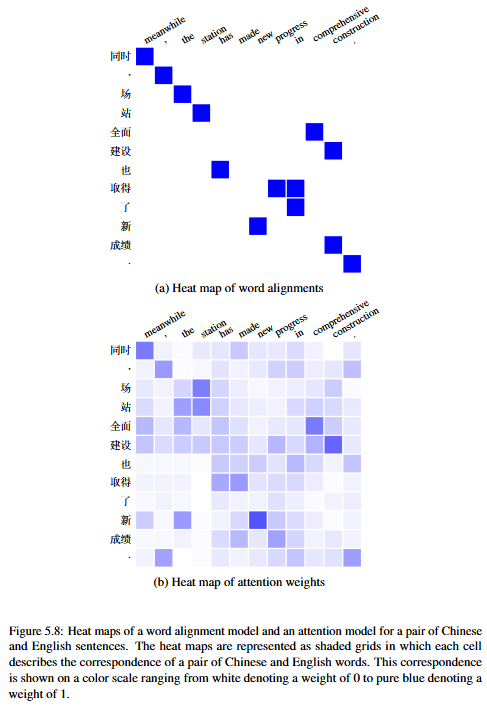

Cả hai đều assign weights cho cặp từ, nhưng **mục tiêu khác nhau:**

| | Word Alignment | Attention |
|---|---|---|
| **Vai trò** | Hệ thống độc lập | Component trong mạng lớn |
| **Output** | Biến rời rạc (alignment links) | Biểu diễn liên tục |
| **Train** | Riêng biệt | End-to-end cùng mô hình |

### 2. Attention với Prior

Kết hợp learned attention với prior knowledge:

$$\tilde{\Pr}(h_j \mid s_i) = \eta \cdot \Pr(h_j \mid s_i) + (1-\eta) \cdot \text{Prior} \tag{5.59}$$

**Local attention:** Giới hạn attention trong cửa sổ $[\rho_i - D, \rho_i + D]$ → hiệu quả hơn cho câu dài.

**Gaussian prior:** Attention tập trung quanh một điểm focal và giảm dần theo khoảng cách.

### 3. Attention như Bộ Nhớ

QKV attention = **retrieval từ memory bank:**
- Memory = $\{h_1,\ldots,h_m\}$ (source encodings)
- Query = $s_i$ (decoder state)
- Retrieval = $c_i$ (context vector)

Đây là kết nối trực tiếp với memory networks (Mục 4.3).

### 4. Self-Attention và Ứng Dụng Tổng Quát

Self-attention ($Q=K=V=H$) không chỉ cho seq2seq — áp dụng được cho **bất kỳ cấu trúc dữ liệu nào**:
- Graphs: mỗi node query các node khác
- Multi-modal: text attend vào image
- Co-attention: hai sequences attend lẫn nhau

**Lưu ý:** Attention **invariant với thứ tự** → cần positional encoding (Chương 4, 6).

---

## Tổng Kết Mục 5.3

```
Attention: giải quyết information bottleneck của encoder-decoder

Basic Attention:
  ci = Σj αi,j · hj          (context vector)
  αi,j = softmax(a(si, hj))   (attention weights)
  
  Alignment scores a(si,hj):
    Dot-product:    sihjᵀ
    Scaled:         sihjᵀ/β
    Multiplicative: siWahjᵀ
    Additive:       vaᵀ TanH(siWs + hjWh)

QKV Attention:
  C = Softmax(QKᵀ/β) · V
  
  Encoder-Decoder: Q=S, K=V=H
  Self-Attention:  Q=K=V=H  (→ Transformer)

Multi-head:  τ heads song song trong τ subspaces
Multi-layer: Sl = FFN(Att(H, Sl-1)) + Sl-1
```

| Thành phần | Chức năng |
|---|---|
| Alignment score $a(s_i, h_j)$ | Đo mức liên quan giữa target state và source state |
| Attention weight $\alpha_{i,j}$ | Phân phối xác suất trên source |
| Context vector $c_i$ | Biểu diễn source thích ứng với target state hiện tại |
| Multi-head | Capture nhiều loại quan hệ song song |
| Self-attention | Nền tảng Transformer — từng phần tử attend vào toàn chuỗi |

> **Kết nối then chốt:** Self-attention (Q=K=V=H) + Positional Encoding + Multi-head + Multi-layer + Residual = **Transformer** (Chương 6) — kiến trúc state-of-the-art cho hầu hết NLP tasks hiện đại.

# 5.4 Tìm Kiếm (Search / Decoding)

---

## Bài Toán

$$\hat{y} = \arg\max_{y \in \Omega} \text{Score}(x, y) \tag{5.61}$$

**Thách thức:** Số hypothesis tăng theo cấp số nhân — vocabulary $|V_y| = 20000$, độ dài $n = 20$ → $\sim 10^{86}$ candidates. Exhaustive search là bất khả thi.

---

## 5.4.1 Vấn Đề Độ Dài (Length Problem)

**Nguyên nhân:** $\log\Pr(y|x) = \sum_{i=1}^n \log\Pr(y_i|y_{<i},x)$ — tổng $n$ số âm → **chuỗi ngắn luôn có score cao hơn**.

**Các giải pháp:**

**Length Reward** — thưởng thêm cho mỗi từ:
$$\text{Score}(x,y) = \log\Pr(y|x) + \lambda \cdot n \tag{5.64}$$

**Length Normalization** — chia cho độ dài:
$$\text{Score}(x,y) = \frac{\log\Pr(y|x)}{n} \tag{5.67}$$

**GNMT-style** — normalization mềm hơn:
$$\text{Score}(x,y) = \frac{\log\Pr(y|x)}{(5+n)^\alpha/(5+1)^\alpha} + c_p(x,y) \tag{5.76}$$

**Coverage penalty** $c_p$ — phạt under-translation, dùng tổng attention weights:

$$\upsilon_j = \sum_{i=1}^n \alpha_{i,j} \quad \text{(số lần từ nguồn $x_j$ được "dịch")} \tag{5.72}$$

$$c_p(x,y) = \beta \sum_{j=1}^m \log(\min(\upsilon_j, 1)) \tag{5.73}$$

Nếu $\upsilon_j < 1$ → $x_j$ chưa được dịch đủ → bị phạt.

---

## 5.4.2 Pruning và Beam Search

### Cấu Trúc Tìm Kiếm

Mỗi hypothesis là chuỗi target đang xây dựng. Tại mỗi bước $i$, mở rộng hypothesis $z_{\text{cur}}$ với từ $v_k$:

$$z_{\text{next}}^k.\text{tgt} = z_{\text{cur}}.\text{tgt} \circ v_k \tag{5.78}$$

$$\log\Pr(z_{\text{next}}.\text{tgt}|x) = \log\Pr(z_{\text{cur}}.\text{tgt}|x) + \log\Pr(v_k|z_{\text{cur}}.\text{tgt}, x) \tag{5.80}$$

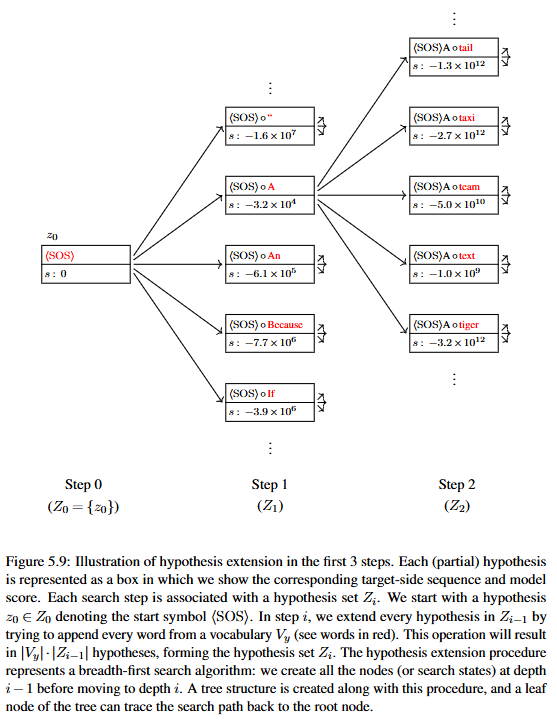

**Breadth-first search đơn giản:** Giữ tất cả hypotheses → exponential, không khả thi.

### Greedy Search

Tại mỗi bước, chọn **một từ tốt nhất duy nhất**:

$$\hat{y}_i = \arg\max_{v_k \in V_y} \Pr(v_k|y_{<i}, x) \tag{5.82}$$

Nhanh nhất nhưng dễ bị kẹt ở local optimum.

### Beam Search

Duy trì **beam** gồm $B$ hypotheses tốt nhất tại mỗi bước:

1. Khởi tạo beam: $Z_0 = \{z_0\}$ với $z_0.\text{tgt} = \langle\text{SOS}\rangle$
2. Tại mỗi bước $i$: mở rộng tất cả $B$ hypotheses với toàn bộ vocabulary → $B \times |V_y|$ candidates
3. Giữ lại $B$ candidates có score cao nhất → beam mới $Z_i$
4. Hypothesis kết thúc bằng $\langle\text{EOS}\rangle$ → đưa vào heap
5. Dừng khi heap đầy hoặc đủ điều kiện

> **Beam size $B$:** $B=1$ = greedy; $B=\infty$ = exhaustive. Thực tế thường $B = 4\text{-}10$.

**Đánh đổi:**
- $B$ lớn: chất lượng tốt hơn, tốn kém hơn
- $B$ nhỏ: nhanh, có thể bỏ lỡ hypothesis tốt

---

## 5.4.3-5.4.5 Các Biến Thể Search

**Greedy Search:** $B=1$ — chọn từ tốt nhất tại mỗi bước, nhanh nhất.

**Sampling:** Thay argmax bằng sampling từ $\Pr(\cdot|y_{<i},x)$ → đa dạng hơn, dùng trong generation sáng tạo.

**Continuous Relaxation:** Thay biến rời rạc $y_i$ bằng vectơ liên tục $y_i^w \in \Delta^{|V_y|}$ (simplex):

$$(\hat{y}_0^w,\ldots,\hat{y}_n^w) = \arg\max \sum_{i=1}^n y_i^w \cdot \log\Pr(\cdot|y_{<i}^w, x) \tag{5.106}$$

Dùng gradient descent thay vì discrete search → tìm nghiệm tốt hơn về mặt lý thuyết.

---

## 5.4.6 Đa Dạng Hypothesis (Hypothesis Diversity)

**Vấn đề:** Beam search thường cho $B$ hypotheses **rất giống nhau** — chỉ khác vài từ.

**Nguyên nhân:** Hypotheses khác nhau sớm bị loại khỏi beam ở bước trung gian dù cuối cùng có thể tốt.

**Giải pháp:**

$$\text{Score}_d(x,y) = \text{Score}(x,y) - \lambda \cdot d_p \tag{5.107}$$

$d_p$ là diversity penalty — phạt hypotheses quá giống nhau trong beam.

Các cách định nghĩa $d_p$:
- Phạt hypotheses chia sẻ cùng parent node trong search tree
- Đo string similarity trung bình giữa các hypotheses
- Thêm random noise vào beam

---

## 5.4.7 Kết Hợp Nhiều Mô Hình (Ensemble)

**Prediction averaging** — trung bình log-probability từ $K$ models:

$$\log\Pr(y_i|y_{<i},x) = \frac{1}{K}\sum_{k=1}^K \log\Pr_k(y_i|y_{<i},x) \tag{5.109}$$

Đơn giản, hiệu quả, không cần sửa đổi kiến trúc. Yêu cầu: $K$ models phải đủ **đa dạng** mới có ích.

**Checkpoint ensembling:** Dùng nhiều snapshots của cùng một model ở các checkpoint training khác nhau → giảm overfitting.

**Sequence-level ensembling (black-box):** Khi không có access vào step-wise probabilities → chọn hypothesis tốt nhất từ pool outputs của nhiều systems.

---

## 5.4.8 Các Hàm Mục Tiêu Search Khác

### A* Search với Future Score

$$\text{Score}_{A^*}(x, y_{\leq i}) = g(x, y_{\leq i}) + h(x, y_{\leq i}) \tag{5.111}$$

- $g$: tổng reward đã tích lũy (= log prob hiện tại)
- $h$: ước lượng reward tương lai (future score)

Khi $h=0$ → beam/greedy search thông thường. $h$ tốt → tìm kiếm hiệu quả hơn.

### Search với Language Model

$$\text{Score}_{lm}(x,y) = \log\Pr(y|x) + \lambda \cdot \log\Pr(y) \tag{5.114}$$

$\lambda > 0$: ưu tiên fluency. $\lambda < 0$: ưu tiên diversity (khi $\lambda=-1$ → PMI score).

### Minimum Bayes Risk (MBR) Search

Thay vì tìm hypothesis có **probability cao nhất** (MAP), tìm hypothesis có **risk thấp nhất** theo metric đánh giá:

$$\hat{y} = \arg\min_y \sum_{y_r \in \Omega_{\text{system}}} R(y, y_r) \cdot \Pr(y_r|x) \tag{5.120}$$

$R(y, y_r)$ = risk function (ví dụ: $1 - \text{BLEU}$). $\Omega_{\text{system}}$ = tập $k$-best hypotheses.

**Ưu điểm MBR:** Tích hợp trực tiếp evaluation metric vào decoding, giảm bias của MAP search, phản ánh full distribution thay vì chỉ mode.

---

## Tổng Kết Mục 5.4

```
Search Methods:
  Greedy:      B=1, nhanh nhất, chất lượng thấp
  Beam Search: duy trì B hypotheses, cân bằng tốt
  Exhaustive:  B=∞, chính xác nhưng bất khả thi

Scoring refinements:
  Length reward/normalization   → tránh bias ngắn
  Coverage penalty              → tránh under/over-translation
  Diversity penalty             → đa dạng hypotheses
  Ensemble averaging            → kết hợp nhiều models
  MBR                          → tối ưu theo metric thực tế

B (beam size) trade-off:
  Lớn → chất lượng tốt hơn, tốn kém hơn
  Nhỏ → nhanh, dễ miss hypothesis tốt
```

| Phương pháp | Score | Ưu điểm | Nhược điểm |
|---|---|---|---|
| Greedy | argmax 1 từ | Rất nhanh | Suboptimal |
| Beam Search | Top-B | Cân bằng | Hypotheses giống nhau |
| Diverse Beam | Top-B + diversity penalty | Đa dạng hơn | Phức tạp hơn |
| MBR | Min risk | Align với metric | Cần sample pool |